# P300 EEG -> Adaptive-LIF SNN classifier (block-averaged)



In [ ]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


# CONFIG


DATA_ROOT = Path("../data")     # same as  original notebook — change only if needed
SUBJECT = "SBJ01"
SESSIONS = None                 # None = auto-discover and use ALL sessions for this subject

FS = 250
LOWCUT = 0.1
HIGHCUT = 20.0

N_OBJECTS = 8            # objects in the P300 speller matrix (adjust if different)
EPOCHS_PER_BLOCK = 80    # 10 runs x 8 objects, same as your original BLOCK_SIZE

N_HIDDEN = 64
DROPOUT = 0.3
BATCH_SIZE = 32
N_EPOCHS = 100
LR = 3e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 20
DOWNSAMPLE_FACTOR = 2    # 350 -> 175 timesteps: shortens BPTT and roughly halves training time
LOGIT_SCALE_INIT = 10.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 1. Data loading — ALL blocks, ALL sessions for the subject

Loads every session on disk for the subject (not just one block). Also keeps `events` (which object was flashed on each epoch) and a block-group id per epoch — both needed for the block-averaging step below.

In [3]:
def discover_sessions(subject_dir):
    return sorted(p for p in subject_dir.glob("S*") if (p / "Train").exists())


def load_session_train(session_dir):
    train_dir = session_dir / "Train"

    mat = loadmat(train_dir / "trainData.mat")
    data_vars = {k: v for k, v in mat.items() if not k.startswith("__")}
    eeg = list(data_vars.values())[0]                      # (channels, samples, epochs)
    X = np.transpose(eeg, (2, 0, 1)).astype(np.float32)     # (epochs, channels, samples)

    targets = np.loadtxt(train_dir / "trainTargets.txt", dtype=int).flatten()
    events = np.loadtxt(train_dir / "trainEvents.txt", dtype=int).flatten()

    block_ids = np.arange(len(targets)) // EPOCHS_PER_BLOCK
    return X, targets, events, block_ids


def load_subject_epochs(data_root, subject, sessions=None):
    subject_dir = data_root / subject
    session_dirs = (
        discover_sessions(subject_dir) if sessions is None
        else [subject_dir / s for s in sessions]
    )

    all_X, all_y, all_events, all_groups = [], [], [], []
    for session_dir in session_dirs:
        X, y, events, block_ids = load_session_train(session_dir)
        groups = [f"{session_dir.name}_B{b}" for b in block_ids]
        all_X.append(X)
        all_y.append(y)
        all_events.append(events)
        all_groups.extend(groups)
        print(f"  {session_dir.name}: {X.shape[0]} epochs "
              f"({int((y == 1).sum())} target / {int((y == 0).sum())} non-target)")

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    events = np.concatenate(all_events, axis=0)
    groups = np.array(all_groups)
    return X, y, events, groups


print(f"Loading all sessions for {SUBJECT} ...")
X_raw, y_all, events_all, groups_all = load_subject_epochs(DATA_ROOT, SUBJECT, SESSIONS)
print(f"\nTotal epochs: {X_raw.shape[0]}  "
      f"(target={int((y_all == 1).sum())}, non-target={int((y_all == 0).sum())})")

Loading all sessions for SBJ01 ...
  S01: 1600 epochs (200 target / 1400 non-target)
  S02: 1600 epochs (200 target / 1400 non-target)
  S03: 1600 epochs (200 target / 1400 non-target)
  S04: 1600 epochs (200 target / 1400 non-target)
  S05: 1600 epochs (200 target / 1400 non-target)
  S06: 1600 epochs (200 target / 1400 non-target)
  S07: 1600 epochs (200 target / 1400 non-target)

Total epochs: 11200  (target=1400, non-target=9800)


### 2. Preprocessing

Same band-pass filter, baseline correction (-200 to 0 ms), and per-channel z-score normalization as your original Phase 1.

In [4]:
def preprocess_eeg(X, fs=250, lowcut=0.1, highcut=20.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    X_filt = filtfilt(b, a, X, axis=-1)

    baseline_samples = int(0.2 * fs)  # epoch starts at -200 ms
    baseline_mean = X_filt[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    X_bc = X_filt - baseline_mean

    ch_mean = X_bc.mean(axis=2, keepdims=True)
    ch_std = X_bc.std(axis=2, keepdims=True)
    X_norm = (X_bc - ch_mean) / (ch_std + 1e-8)
    return X_norm.astype(np.float32)


print("Preprocessing (bandpass + baseline correction + z-score)...")
X_prep = preprocess_eeg(X_raw, FS, LOWCUT, HIGHCUT)
print("Preprocessed shape:", X_prep.shape)

Preprocessing (bandpass + baseline correction + z-score)...
Preprocessed shape: (11200, 8, 350)


In [5]:
X_prep

array([[[ 0.982859  ,  0.80434227,  0.6188134 , ..., -0.06945638,
         -0.11515908, -0.17000212],
        [ 0.9172648 ,  0.5224153 ,  0.1608994 , ...,  0.16288055,
          0.15749891,  0.12651868],
        [ 1.0429447 ,  0.5815501 ,  0.160937  , ...,  0.05829391,
          0.03592144, -0.02800262],
        ...,
        [ 0.83115286,  0.6281875 ,  0.43826854, ..., -0.11606819,
         -0.13799843, -0.1714294 ],
        [ 0.7568666 ,  0.3717779 ,  0.03227817, ...,  0.05765829,
          0.0296194 , -0.01834527],
        [ 0.6372817 ,  0.2905958 , -0.01525687, ...,  0.1381612 ,
          0.10667461,  0.06388509]],

       [[-1.5891734 , -1.2381656 , -0.89934856, ..., -1.2056304 ,
         -0.8990851 , -0.5393039 ],
        [-1.3585674 , -0.973158  , -0.6039595 , ..., -1.3325125 ,
         -1.0940384 , -0.8176033 ],
        [-1.2229216 , -0.8346201 , -0.46374533, ..., -0.98310596,
         -0.7793724 , -0.54469293],
        ...,
        [-1.1726485 , -0.86727756, -0.5804926 , ..., -

### 3. Signal diagnostic — is there separable signal, and does averaging help?

Two cheap checks (seconds, not hours) before spending time training the SNN:
1. A trivial linear baseline (LDA / logistic regression on mean P300-window amplitude, cross-validated) on single trials — this is what first revealed the SNN was underperforming a two-line linear model on the same data.
2. The same check after collapsing repeated flashes of the same object within a block into one averaged epoch.

If both numbers come back near 0.5, the problem is upstream of any model (channels, timing, artifacts) and no amount of SNN tuning will fix it. If single-trial is clearly above 0.5 but the SNN still lands near 0.5 later in this notebook, that's a pipeline gap, not a data gap — worth revisiting the encoding step.

In [6]:
t_axis = np.arange(X_prep.shape[2]) / FS - 0.2   # epoch starts at -200 ms
p300_mask = (t_axis >= 0.25) & (t_axis <= 0.6)

# ---- 1. Single-trial linear baseline ----
feat_single = X_prep[:, :, p300_mask].mean(axis=2)   # (epochs, channels)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_single = cross_val_score(LinearDiscriminantAnalysis(), feat_single, y_all, cv=cv, scoring="roc_auc")
auc_lr_single = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_single, y_all, cv=cv, scoring="roc_auc")

print("SINGLE-TRIAL linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_single.mean():.3f} +/- {auc_lda_single.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_single.mean():.3f} +/- {auc_lr_single.std():.3f}")
print("  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present")

SINGLE-TRIAL linear baselines (cross-val ROC-AUC):
  LDA:                 0.571 +/- 0.015
  Logistic Regression:  0.572 +/- 0.015
  ~0.5 => no separable signal in this window/preprocessing; >0.6 => signal is present


### 4. Block averaging

Collapses the repeated flashes of each object within a block into one averaged epoch — standard P300-speller SNR-boosting practice. This is the dataset the main path trains on below.

In [7]:
def build_block_averaged_dataset(X, y, events, groups):
    unique_groups = np.unique(groups)
    avg_X, avg_y, avg_group = [], [], []
    for g in unique_groups:
        block_mask = groups == g
        block_X = X[block_mask]
        block_y = y[block_mask]
        block_events = events[block_mask]
        for obj in np.unique(block_events):
            obj_mask = block_events == obj
            avg_X.append(block_X[obj_mask].mean(axis=0))
            avg_y.append(int(block_y[obj_mask][0]))   # constant within (block, object) group
            avg_group.append(g)
    return (np.array(avg_X, dtype=np.float32),
            np.array(avg_y, dtype=np.int64),
            np.array(avg_group))


X_avg, y_avg, groups_avg = build_block_averaged_dataset(X_prep, y_all, events_all, groups_all)
print(f"Block-averaged dataset: {X_avg.shape[0]} examples "
      f"({int(y_avg.sum())} target / {int((y_avg == 0).sum())} non-target), shape {X_avg.shape}")

# same diagnostic, on the averaged epochs, to confirm the SNR boost before training
feat_avg = X_avg[:, :, p300_mask].mean(axis=2)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_lda_avg = cross_val_score(LinearDiscriminantAnalysis(), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
auc_lr_avg = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=1000), feat_avg, y_avg, cv=cv2, scoring="roc_auc")
print("\nBLOCK-AVERAGED linear baselines (cross-val ROC-AUC):")
print(f"  LDA:                 {auc_lda_avg.mean():.3f} +/- {auc_lda_avg.std():.3f}")
print(f"  Logistic Regression:  {auc_lr_avg.mean():.3f} +/- {auc_lr_avg.std():.3f}")

Block-averaged dataset: 1120 examples (140 target / 980 non-target), shape (1120, 8, 350)

BLOCK-AVERAGED linear baselines (cross-val ROC-AUC):
  LDA:                 0.713 +/- 0.060
  Logistic Regression:  0.676 +/- 0.049


In [16]:
feat_avg

array([[-0.0121405 , -0.06494962, -0.05878421, ..., -0.05195774,
        -0.15416382, -0.10700297],
       [-0.25329235, -0.38274312, -0.28498077, ..., -0.18542439,
        -0.25310227, -0.21141449],
       [-0.1501955 , -0.15849033, -0.12524234, ..., -0.07098923,
        -0.04582767, -0.01645525],
       ...,
       [-0.1487825 , -0.09642024, -0.11200275, ..., -0.22879353,
        -0.21057223, -0.26400718],
       [ 0.24968235,  0.11168312,  0.09502903, ...,  0.14305611,
         0.06716755,  0.07600813],
       [-0.04252994, -0.07577894, -0.09728535, ..., -0.02876206,
         0.01754579,  0.00329063]], shape=(1120, 8), dtype=float32)

In [17]:
X_avg

array([[[-0.02913252, -0.00824658,  0.00579612, ..., -0.1625016 ,
         -0.09707741, -0.02361894],
        [-0.42545462, -0.3544518 , -0.28762278, ..., -0.30744347,
         -0.23074308, -0.13899907],
        [-0.59756744, -0.60328686, -0.6017649 , ..., -0.20965524,
         -0.1250374 , -0.0216384 ],
        ...,
        [-0.1253727 , -0.00748221,  0.104602  , ..., -0.28705245,
         -0.18059632, -0.06350569],
        [-0.3819956 , -0.31287313, -0.24523635, ..., -0.23855737,
         -0.14044152, -0.0284502 ],
        [-0.22595277, -0.10081166,  0.01961742, ..., -0.3393178 ,
         -0.22934744, -0.10723452]],

       [[-0.27435303, -0.24150367, -0.20859161, ..., -0.26444182,
         -0.28476277, -0.2918397 ],
        [-0.45332664, -0.43231598, -0.4111046 , ..., -0.11930493,
         -0.19976032, -0.2719484 ],
        [-0.60481006, -0.52300894, -0.4431983 , ..., -0.13522907,
         -0.2621091 , -0.39153188],
        ...,
        [-0.36224812, -0.26619926, -0.17476663, ..., -

### 5. SNN model and training loop

Same Adaptive-LIF dynamics as before (membrane leak `beta`, adaptation `rho`, surrogate-gradient spike function). Readout is the mean spike rate through a learnable scale, not a raw spike count. `train_snn(...)` bundles the split / train / evaluate loop into one function.

In [8]:
def rate_encode(X, seed=42):
    rng = np.random.default_rng(seed)
    X_min = X.min(axis=2, keepdims=True)
    X_max = X.max(axis=2, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)
    spikes = (rng.random(X_norm.shape) < X_norm).astype(np.float32)
    return spikes


def downsample_time(spikes, factor=2):
    T = spikes.shape[2]
    T_trim = T - (T % factor)
    spikes = spikes[:, :, :T_trim]
    return spikes.reshape(spikes.shape[0], spikes.shape[1], -1, factor).max(axis=3)


class SpikeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane, threshold):
        ctx.save_for_backward(membrane)
        ctx.threshold = threshold
        return (membrane >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        (membrane,) = ctx.saved_tensors
        threshold = ctx.threshold
        grad = 1.0 / (1.0 + torch.abs(membrane - threshold)) ** 2
        return grad_output * grad, None


spike_fn = SpikeFunction.apply


class AdaptiveLIFNet(nn.Module):
    """Hidden layer spikes (genuine SNN dynamics). Output layer is a
    continuous leaky-integrator, NOT a second spiking layer -- see the
    note above this cell for why."""
    def __init__(self, input_size=8, hidden_size=64, output_size=2,
                 beta=0.9, rho=0.95, adapt_strength=0.15,
                 dropout=0.3, threshold=1.0, logit_scale_init=10.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.threshold = threshold
        self.beta = beta
        self.rho = rho
        self.adapt_strength = adapt_strength

        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
        # scaled down from the raw init value since membrane potentials aren't
        # bounded to [0,1] the way a spike rate is
        self.logit_scale = nn.Parameter(torch.tensor(logit_scale_init * 0.1))

    def forward(self, x):
        batch, _, T = x.shape

        v = torch.zeros(batch, self.hidden_size, device=x.device)
        adapt = torch.zeros(batch, self.hidden_size, device=x.device)
        v_out = torch.zeros(batch, self.output_size, device=x.device)

        hidden_trace, membrane_trace = [], []

        for t in range(T):
            x_t = x[:, :, t]

            current = self.dropout(self.fc_in(x_t))
            v = self.beta * v + current - adapt
            s = spike_fn(v, self.threshold)
            v = v * (1.0 - s)
            adapt = self.rho * adapt + self.adapt_strength * s

            out_current = self.fc_out(s)
            v_out = self.beta * v_out + out_current   # continuous leaky-integrator, no reset/threshold here

            hidden_trace.append(s)
            membrane_trace.append(v_out)

        hidden_trace = torch.stack(hidden_trace, dim=1)
        membrane_trace = torch.stack(membrane_trace, dim=1)     # (batch, T, output_size)

        mean_potential = membrane_trace.mean(dim=1)
        logits = mean_potential * self.logit_scale

        return logits, hidden_trace, membrane_trace


def make_splits(y, groups=None, seed=42):
    """Block-grouped split when `groups` is given (keeps every example from the
    same block together, avoiding block-level leakage across train/val/test).
    Falls back to a plain stratified split if no groups are provided."""
    if groups is None:
        idx = np.arange(len(y))
        train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=y, random_state=seed)
        val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx], random_state=seed)
        return train_idx, val_idx, test_idx

    rng = np.random.default_rng(seed)
    unique_groups = np.unique(groups)
    rng.shuffle(unique_groups)

    n = len(unique_groups)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_groups = set(unique_groups[:n_train])
    val_groups = set(unique_groups[n_train:n_train + n_val])
    test_groups = set(unique_groups[n_train + n_val:])

    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    val_idx = np.where(np.isin(groups, list(val_groups)))[0]
    test_idx = np.where(np.isin(groups, list(test_groups)))[0]
    return train_idx, val_idx, test_idx


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Training")
    axes[0].plot(history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(np.array(history["train_acc"]) * 100, label="Training")
    axes[1].plot(np.array(history["val_acc"]) * 100, label="Validation")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_snn(spike_data, y, label, groups=None,
              n_epochs=N_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
              hidden=N_HIDDEN, dropout=DROPOUT, logit_scale_init=LOGIT_SCALE_INIT,
              weight_decay=WEIGHT_DECAY, patience=PATIENCE, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    train_idx, val_idx, test_idx = make_splits(y, groups=groups, seed=seed)
    train_X = torch.tensor(spike_data[train_idx], dtype=torch.float32)
    train_y = torch.tensor(y[train_idx], dtype=torch.long)
    val_X = torch.tensor(spike_data[val_idx], dtype=torch.float32).to(device)
    val_y = torch.tensor(y[val_idx], dtype=torch.long).to(device)
    test_X = torch.tensor(spike_data[test_idx], dtype=torch.float32).to(device)
    test_y = torch.tensor(y[test_idx], dtype=torch.long).to(device)

    print(f"[{label}] Train: {len(train_idx)} (target={(y[train_idx]==1).sum()})  "
          f"Val: {len(val_idx)} (target={(y[val_idx]==1).sum()})  "
          f"Test: {len(test_idx)} (target={(y[test_idx]==1).sum()})")

    model = AdaptiveLIFNet(input_size=8, hidden_size=hidden, output_size=2,
                            dropout=dropout, logit_scale_init=logit_scale_init).to(device)

    n0 = int((train_y == 0).sum()); n1 = int((train_y == 1).sum()); tot = n0 + n1
    class_weights = torch.tensor([tot / (2 * n0), tot / (2 * n1)], dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)

    best_val_bal_acc = -1.0
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"\n[{label}] Training...")
    for epoch in range(n_epochs):
        model.train()
        running_loss, running_correct, running_n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _, _ = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(1) == yb).sum().item()
            running_n += xb.size(0)

        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        model.eval()
        with torch.no_grad():
            val_logits, _, _ = model(val_X)
            val_loss = criterion(val_logits, val_y).item()
            val_pred = val_logits.argmax(1)
            val_bal_acc = balanced_accuracy_score(val_y.cpu().numpy(), val_pred.cpu().numpy())
            val_acc = (val_pred == val_y).float().mean().item()

        scheduler.step(val_bal_acc)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}% BalAcc: {val_bal_acc*100:.1f}%")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1} (best val bal-acc: {best_val_bal_acc*100:.1f}%)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits, test_hidden, test_membrane = model(test_X)
        test_probs = torch.softmax(test_logits, dim=1)[:, 1]
        test_pred = test_logits.argmax(1)

    true = test_y.cpu().numpy(); pred = test_pred.cpu().numpy(); probs = test_probs.cpu().numpy()

    print(f"\n[{label}] FINAL TEST RESULTS")
    print(classification_report(true, pred, target_names=["Non-target", "Target"], zero_division=0))
    print("Balanced accuracy:", balanced_accuracy_score(true, pred))
    try:
        test_auc = roc_auc_score(true, probs)
        print("ROC-AUC:", test_auc)
    except ValueError as e:
        test_auc = float("nan")
        print("ROC-AUC: n/a (", e, ")")
    print("Confusion matrix:")
    print(confusion_matrix(true, pred))

    return {
        "model": model, "history": history,
        "test_true": true, "test_pred": pred, "test_probs": probs,
        "test_hidden_trace": test_hidden.cpu().numpy(),
        "test_membrane_trace": test_membrane.cpu().numpy(),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "roc_auc": test_auc,
    }

## Train and evaluate

Trains and evaluates the SNN on the block-averaged (high-SNR) dataset built above, using the block-grouped split.

In [9]:
spike_avg = rate_encode(X_avg, seed=42)
spike_avg = downsample_time(spike_avg, factor=DOWNSAMPLE_FACTOR)
print("Block-averaged spike train shape:", spike_avg.shape)

results_avg = train_snn(spike_avg, y_avg, label="block-averaged", groups=groups_avg)

Block-averaged spike train shape: (1120, 8, 175)
[block-averaged] Train: 784 (target=98)  Val: 168 (target=21)  Test: 168 (target=21)


KeyboardInterrupt: 

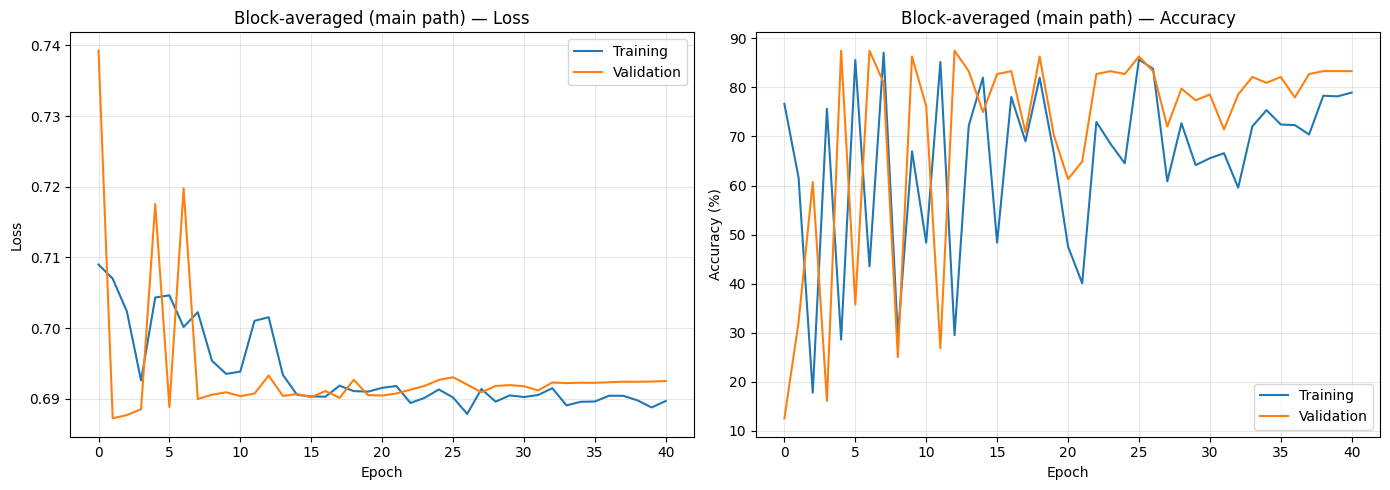

In [ ]:
plot_history(results_avg["history"], title="Block-averaged (main path)")

### Save trajectories for the DDM stage

From the block-averaged model's held-out test set. Since each example here is already an averaged evidence signal across repeated flashes, this trajectory captures the SNN's within-epoch temporal dynamics on top of the across-repeat averaging.

In [18]:
print("Hidden spike trajectory:    ", results_avg["test_hidden_trace"].shape)
print("Output membrane trajectory: ", results_avg["test_membrane_trace"].shape)
print("\nNext stage: output membrane trajectory -> evidence trajectory -> DDM (v, a, t0)")


NameError: name 'results_avg' is not defined